# Enhanced Fully Traditional Method
 It uses 224px spatial handcrafted features and tunes only classical SVM/Random-Forest parameters. 

In [1]:
import sys
from pathlib import Path
REPO = Path('/Users/z5655976/Documents/COMP9517-Group-102')
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
DATA = REPO / 'Team_Dataset'
OUTPUT = REPO / 'artifacts/traditional_enhanced'
print(sys.executable, DATA, OUTPUT, sep='\n')

/Users/z5655976/Documents/COMP9517-Group-102/.venv/bin/python
/Users/z5655976/Documents/COMP9517-Group-102/Team_Dataset
/Users/z5655976/Documents/COMP9517-Group-102/artifacts/traditional_enhanced


## 1. Audit the unchanged splits

In [2]:
from traditional_cv.data import build_manifest
from traditional_cv.enhanced import EnhancedExperimentRunner
manifest = build_manifest(DATA, expected_classes=500, hash_files=False)
display(manifest.frame.groupby('split').size())
enhanced = EnhancedExperimentRunner(manifest, OUTPUT)

split
test      5000
train    20000
val       5000
dtype: int64

## 2. Enhanced feature extraction and validation-only search 

In [3]:
enhanced_results = enhanced.run_validation_search()
display(enhanced_results)


=== Extracting spatial_hsv224 ===


Extracting features:   0%|          | 0/20000 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/5000 [00:00<?, ?it/s]


=== Extracting lbp224 ===


Extracting features:   0%|          | 0/20000 [00:00<?, ?it/s]

...

Fitting SIFT vocabulary:   0%|          | 0/20000 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/20000 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/5000 [00:00<?, ?it/s]


=== Enhanced SVM alpha=1e-05 ===

=== Enhanced SVM alpha=0.0001 ===

=== Enhanced SVM alpha=0.001 ===

=== Regularised RF screen 1/4: {'max_depth': 15, 'min_samples_leaf': 2} ===

=== Regularised RF screen 2/4: {'max_depth': 25, 'min_samples_leaf': 2} ===

=== Regularised RF screen 3/4: {'max_depth': 25, 'min_samples_leaf': 4} ===

=== Regularised RF screen 4/4: {'max_depth': None, 'min_samples_leaf': 4} ===


,family,params,train_accuracy,fit_seconds,top1_accuracy,top5_accuracy,overall_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,inference_seconds,images_per_second
0,stochastic_linear_svm,"{""alpha"": 1e-05}",0.98150,6338.656528,0.0634,0.1730,0.0634,0.0634,0.079761,0.0634,0.063675,1.290830,3873.475753
1,stochastic_linear_svm,"{""alpha"": 0.0001}",0.78310,6849.989815,0.0582,0.1730,0.0582,0.0582,0.074174,0.0582,0.058251,1.012779,4936.908979
6,random_forest_screen,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m...",0.99980,1726.351459,0.0722,0.1828,0.0722,0.0722,0.056422,0.0722,0.056864,1.951340,2562.341338
2,stochastic_linear_svm,"{""alpha"": 0.001}",0.56870,3215.611604,0.0560,0.1620,0.0560,0.0560,0.075543,0.0560,0.054997,0.709044,7051.747717
5,random_forest_screen,"{""max_depth"": 25, ""max_features"": ""sqrt"", ""min...",0.88940,601.318704,0.0568,0.1592,0.0568,0.0568,0.038964,0.0568,0.041323,0.930693,5372.341547
4,random_forest_screen,"{""max_depth"": 25, ""max_features"": ""sqrt"", ""min...",0.85590,622.806892,0.0540,0.1468,0.0540,0.0540,0.038987,0.0540,0.040379,0.843829,5925.369668
3,random_forest_screen,"{""max_depth"": 15, ""max_features"": ""sqrt"", ""min...",0.56885,385.660336,0.0462,0.1360,0.0462,0.0462,0.025461,0.0462,0.030138,0.955841,5230.993479


## 3. Inspect the frozen validation winner


,family,params,train_accuracy,fit_seconds,top1_accuracy,top5_accuracy,overall_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,inference_seconds,images_per_second
0,stochastic_linear_svm,"{""alpha"": 1e-05}",0.9815,6338.656528,0.0634,0.173,0.0634,0.0634,0.079761,0.0634,0.063675,1.29083,3873.475753


,family,params,train_accuracy,fit_seconds,top1_accuracy,top5_accuracy,overall_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,inference_seconds,images_per_second
0,stochastic_linear_svm,"{""alpha"": 1e-05}",0.98150,6338.656528,0.0634,0.1730,0.0634,0.0634,0.079761,0.0634,0.063675,1.290830,3873.475753
1,stochastic_linear_svm,"{""alpha"": 0.0001}",0.78310,6849.989815,0.0582,0.1730,0.0582,0.0582,0.074174,0.0582,0.058251,1.012779,4936.908979
6,random_forest_screen,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m...",0.99980,1726.351459,0.0722,0.1828,0.0722,0.0722,0.056422,0.0722,0.056864,1.951340,2562.341338
2,stochastic_linear_svm,"{""alpha"": 0.001}",0.56870,3215.611604,0.0560,0.1620,0.0560,0.0560,0.075543,0.0560,0.054997,0.709044,7051.747717
5,random_forest_screen,"{""max_depth"": 25, ""max_features"": ""sqrt"", ""min...",0.88940,601.318704,0.0568,0.1592,0.0568,0.0568,0.038964,0.0568,0.041323,0.930693,5372.341547
4,random_forest_screen,"{""max_depth"": 25, ""max_features"": ""sqrt"", ""min...",0.85590,622.806892,0.0540,0.1468,0.0540,0.0540,0.038987,0.0540,0.040379,0.843829,5925.369668
3,random_forest_screen,"{""max_depth"": 15, ""max_features"": ""sqrt"", ""min...",0.56885,385.660336,0.0462,0.1360,0.0462,0.0462,0.025461,0.0462,0.030138,0.955841,5230.993479


metrics_comparison.png


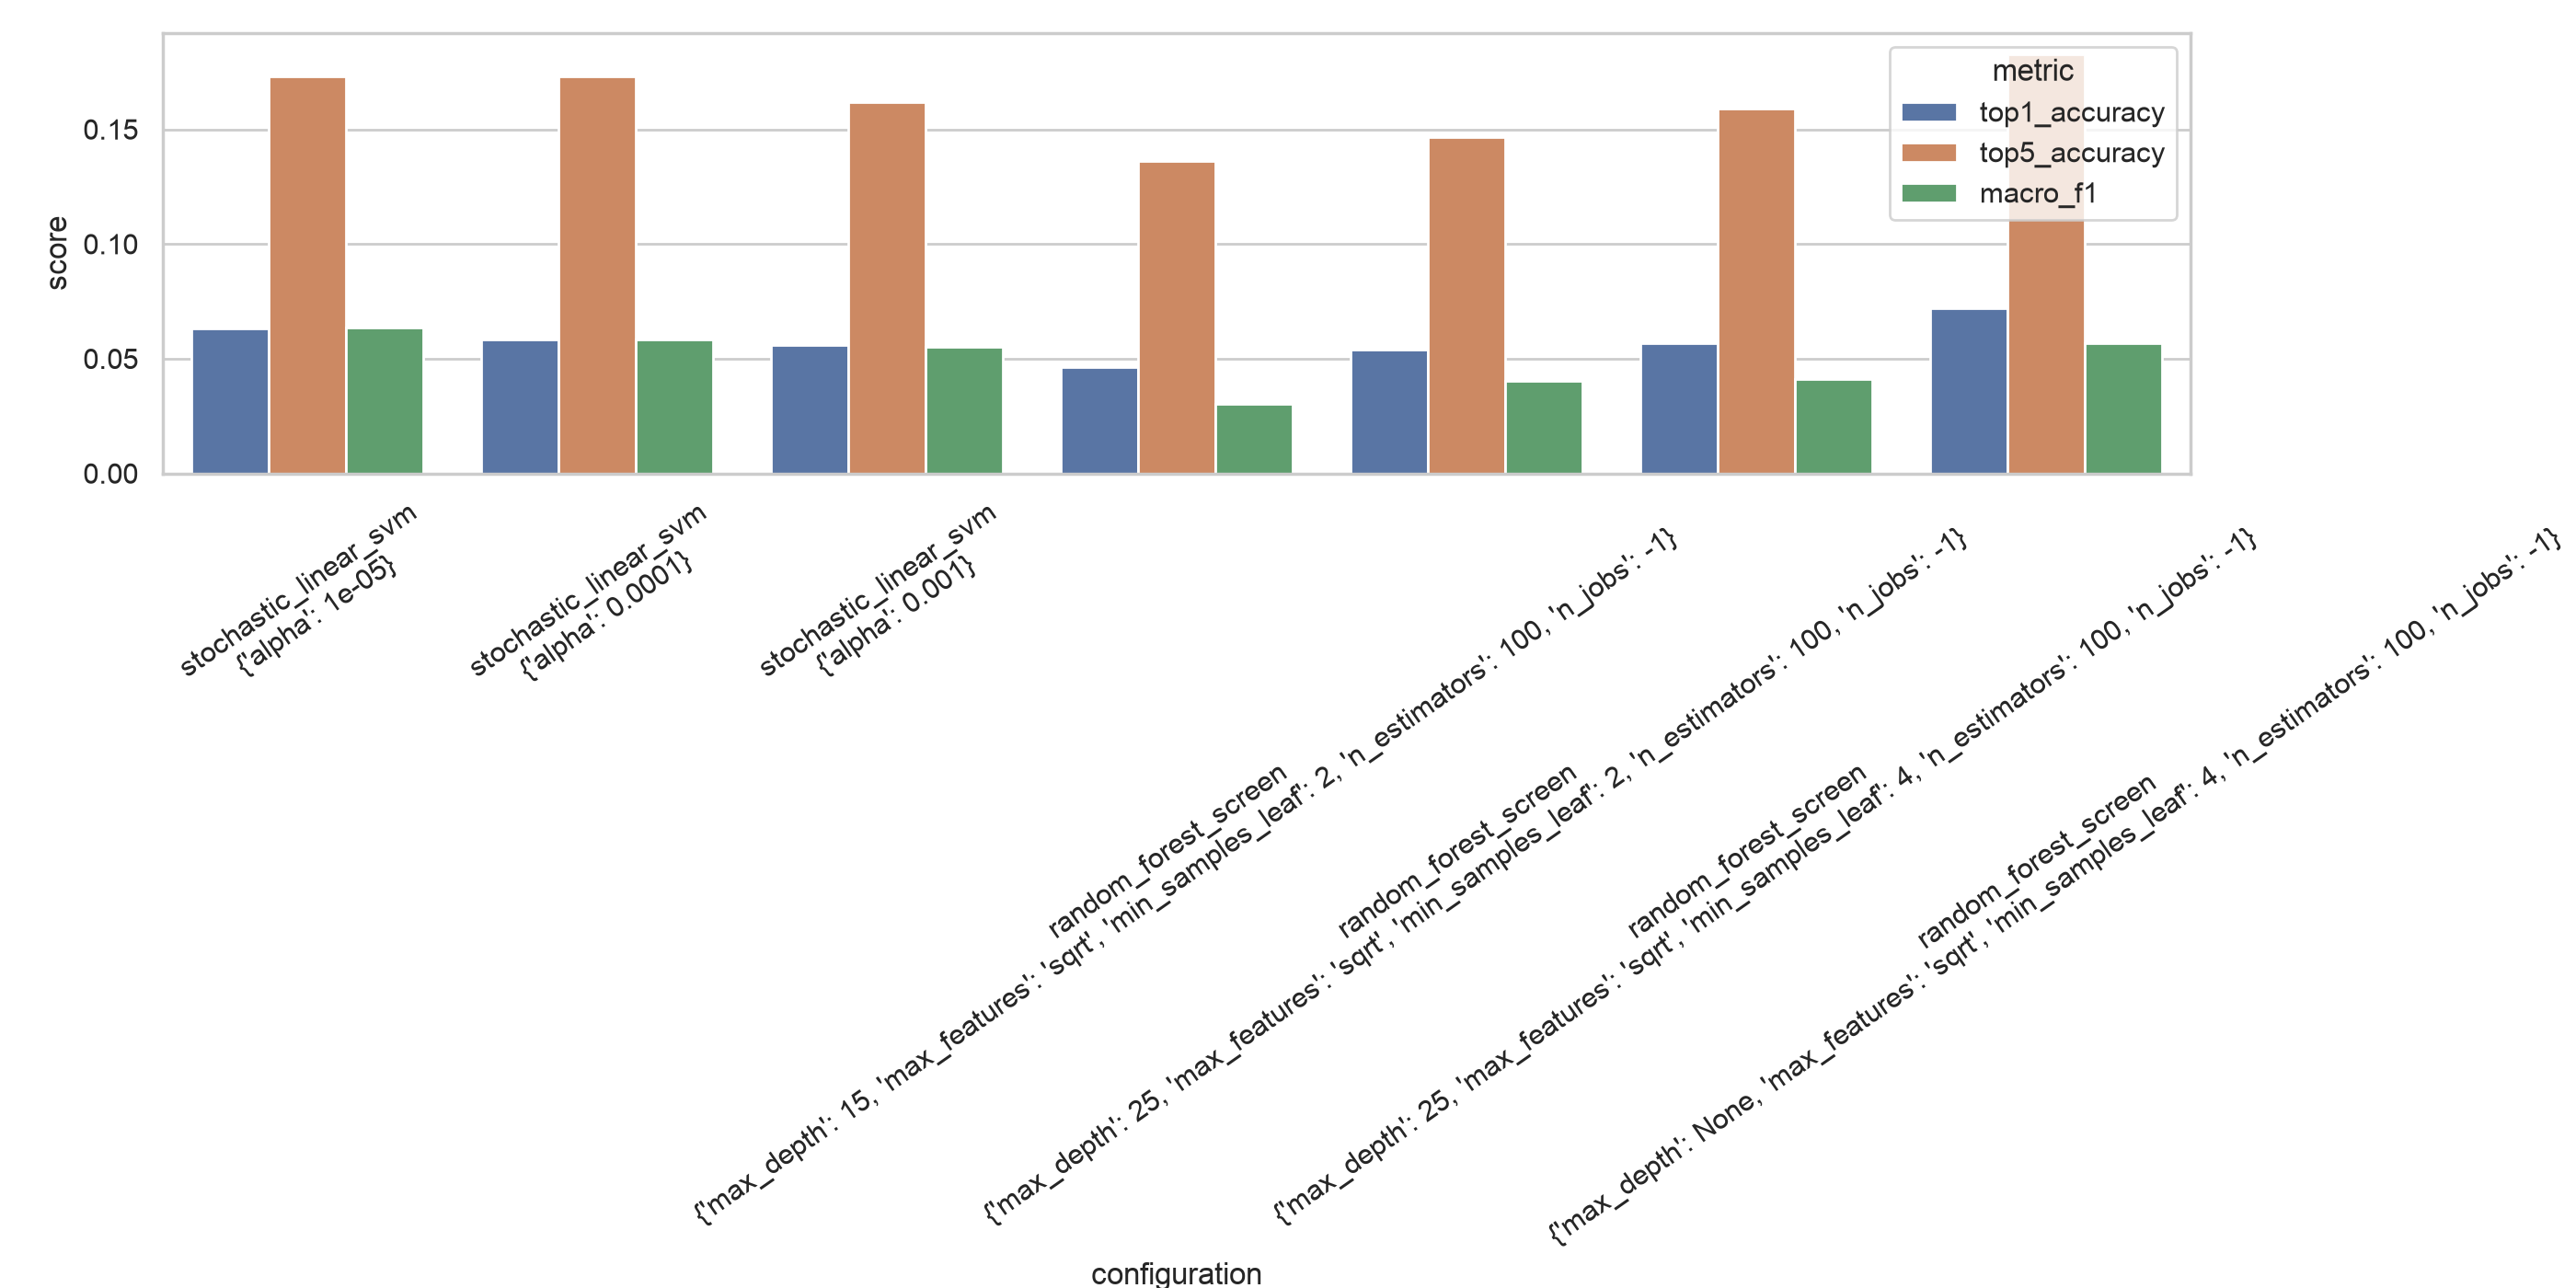

train_validation_gap.png


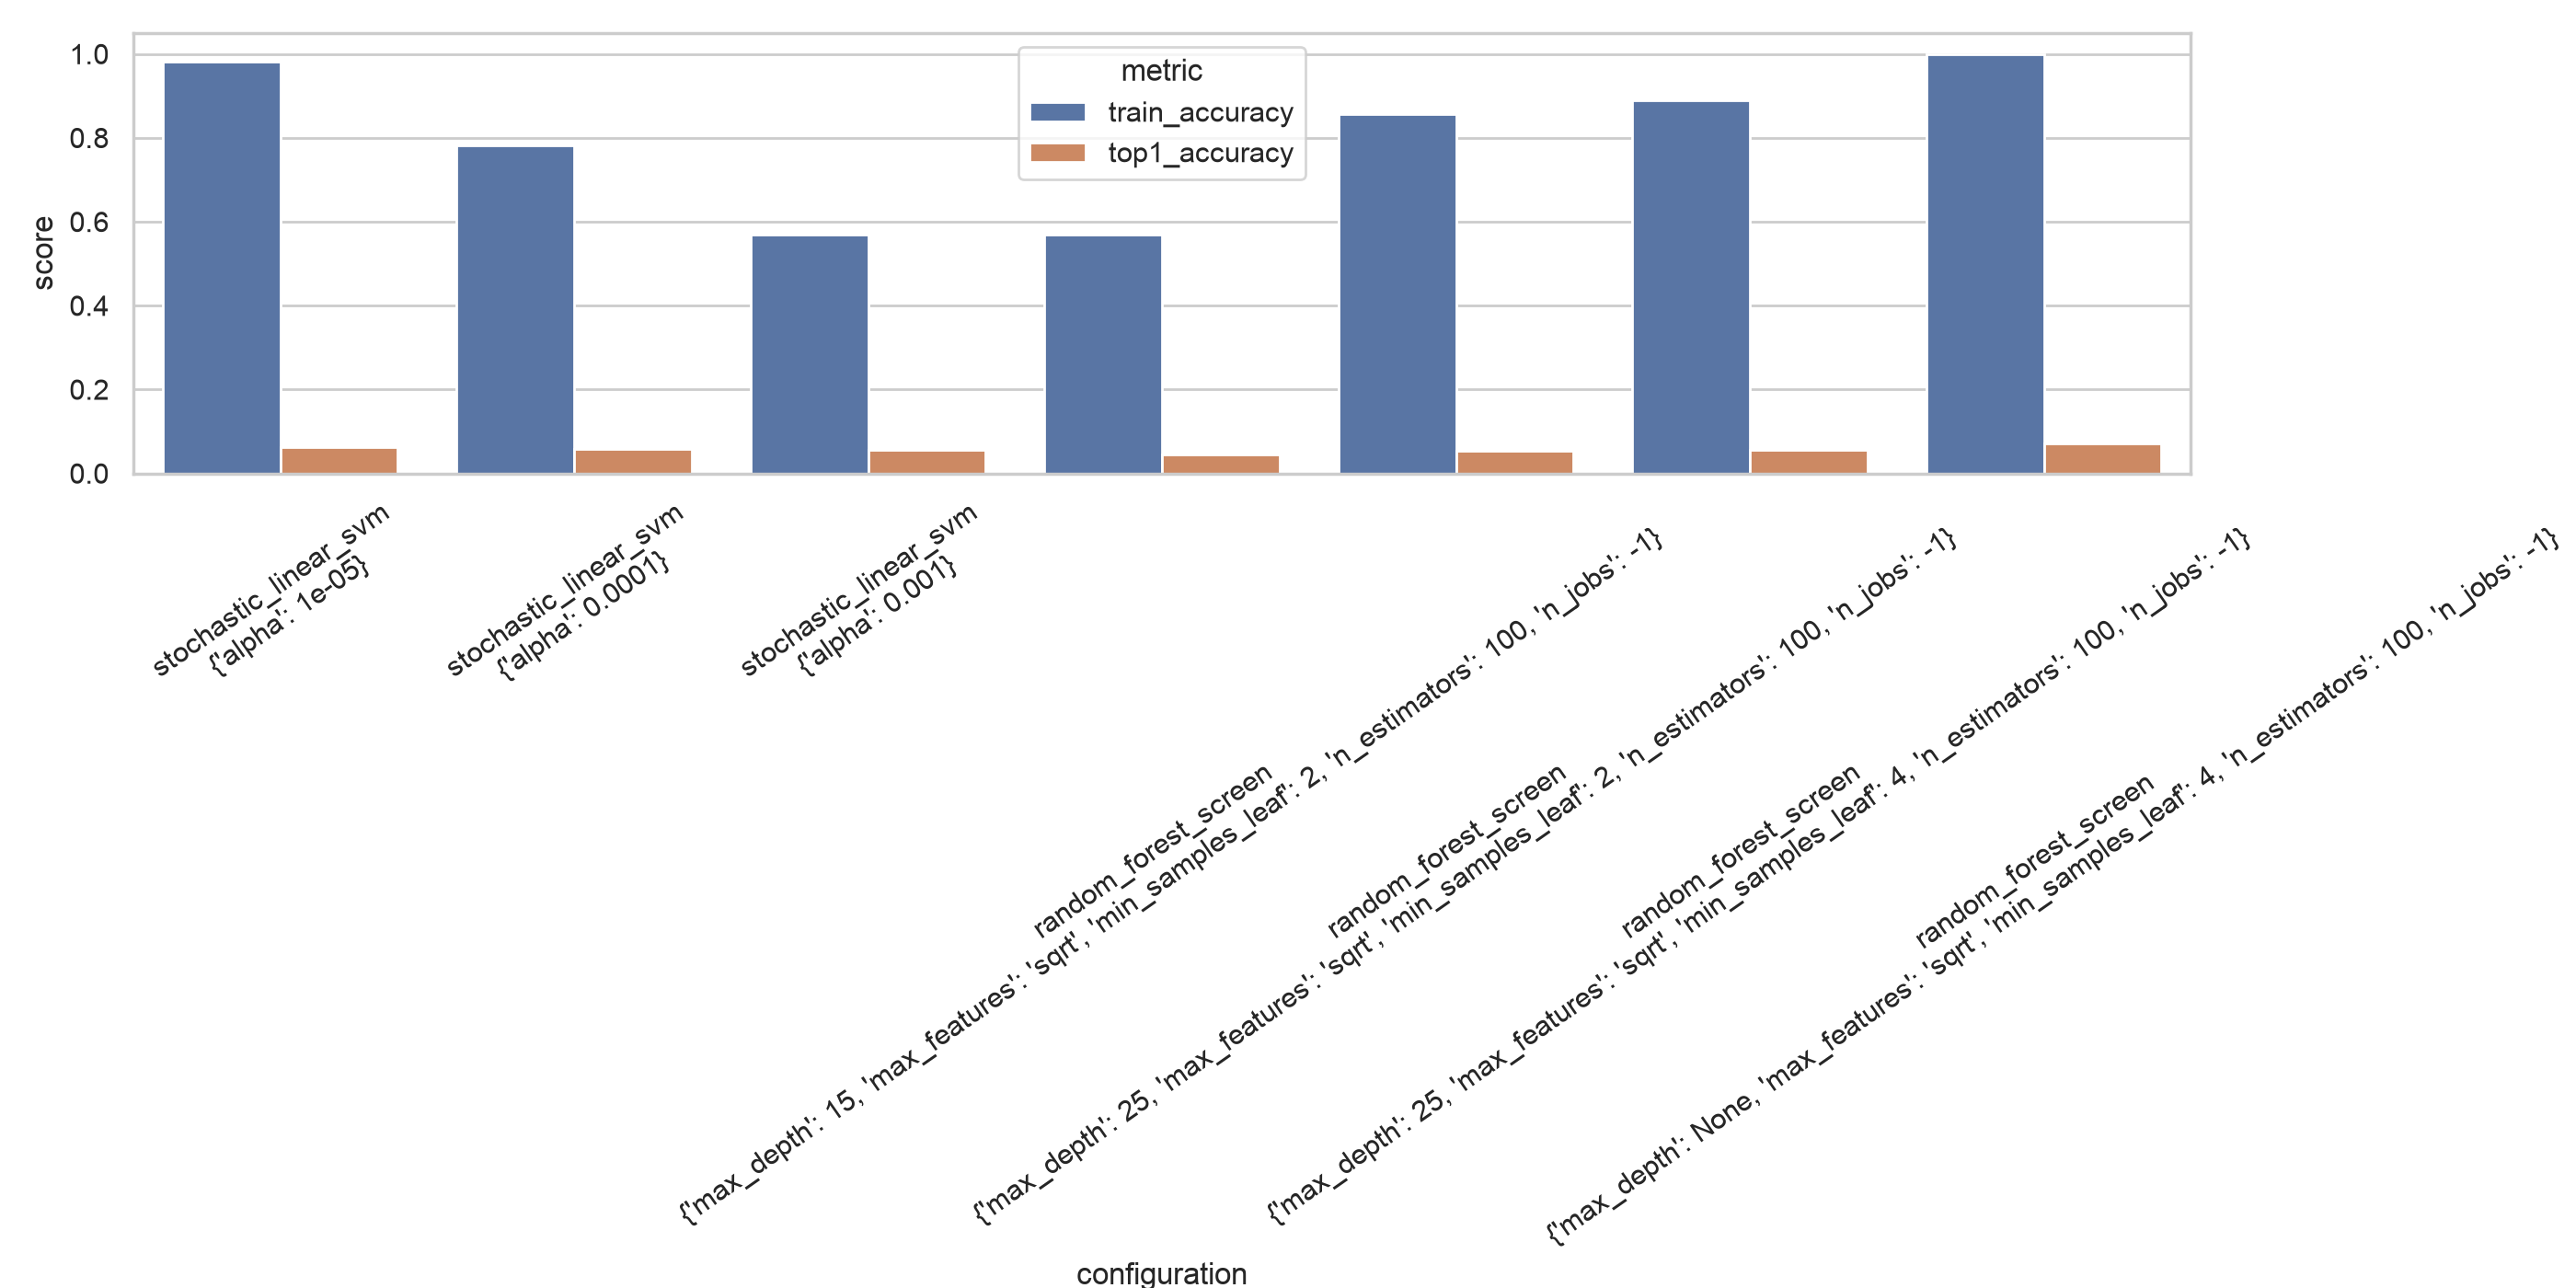

performance_vs_time.png


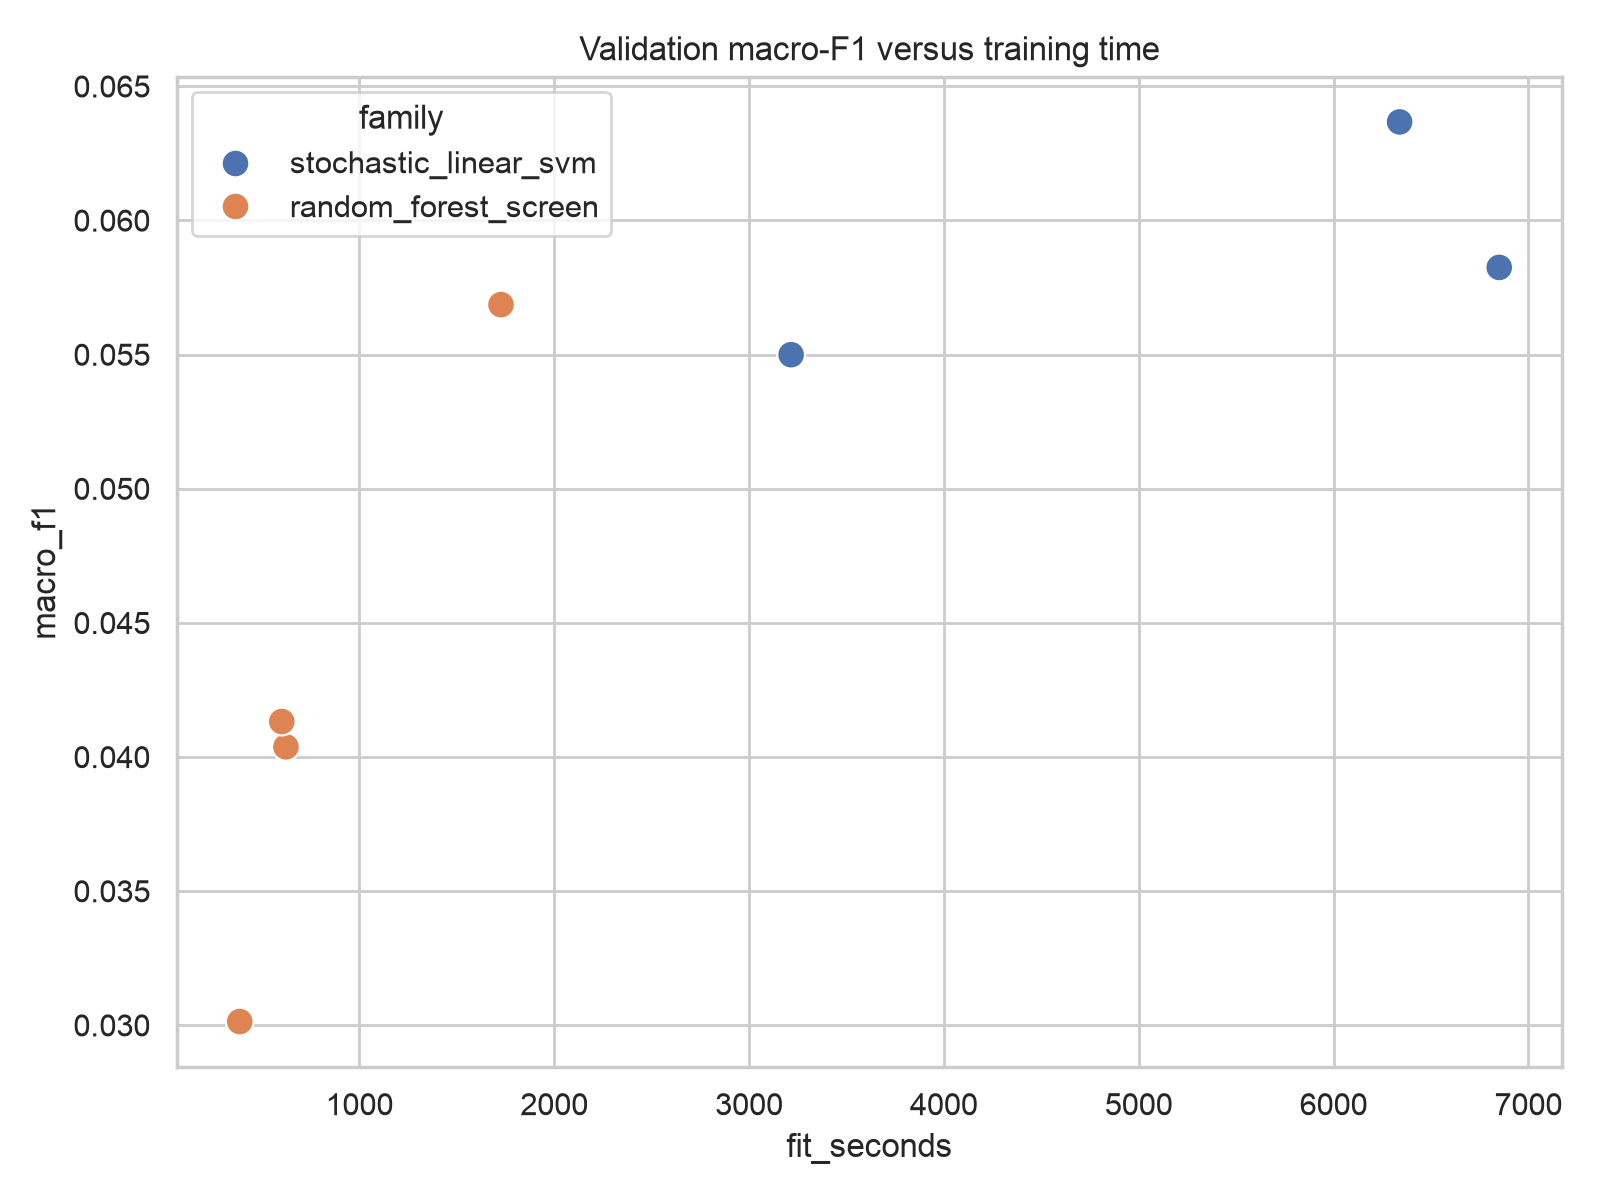

baseline_vs_enhanced.png


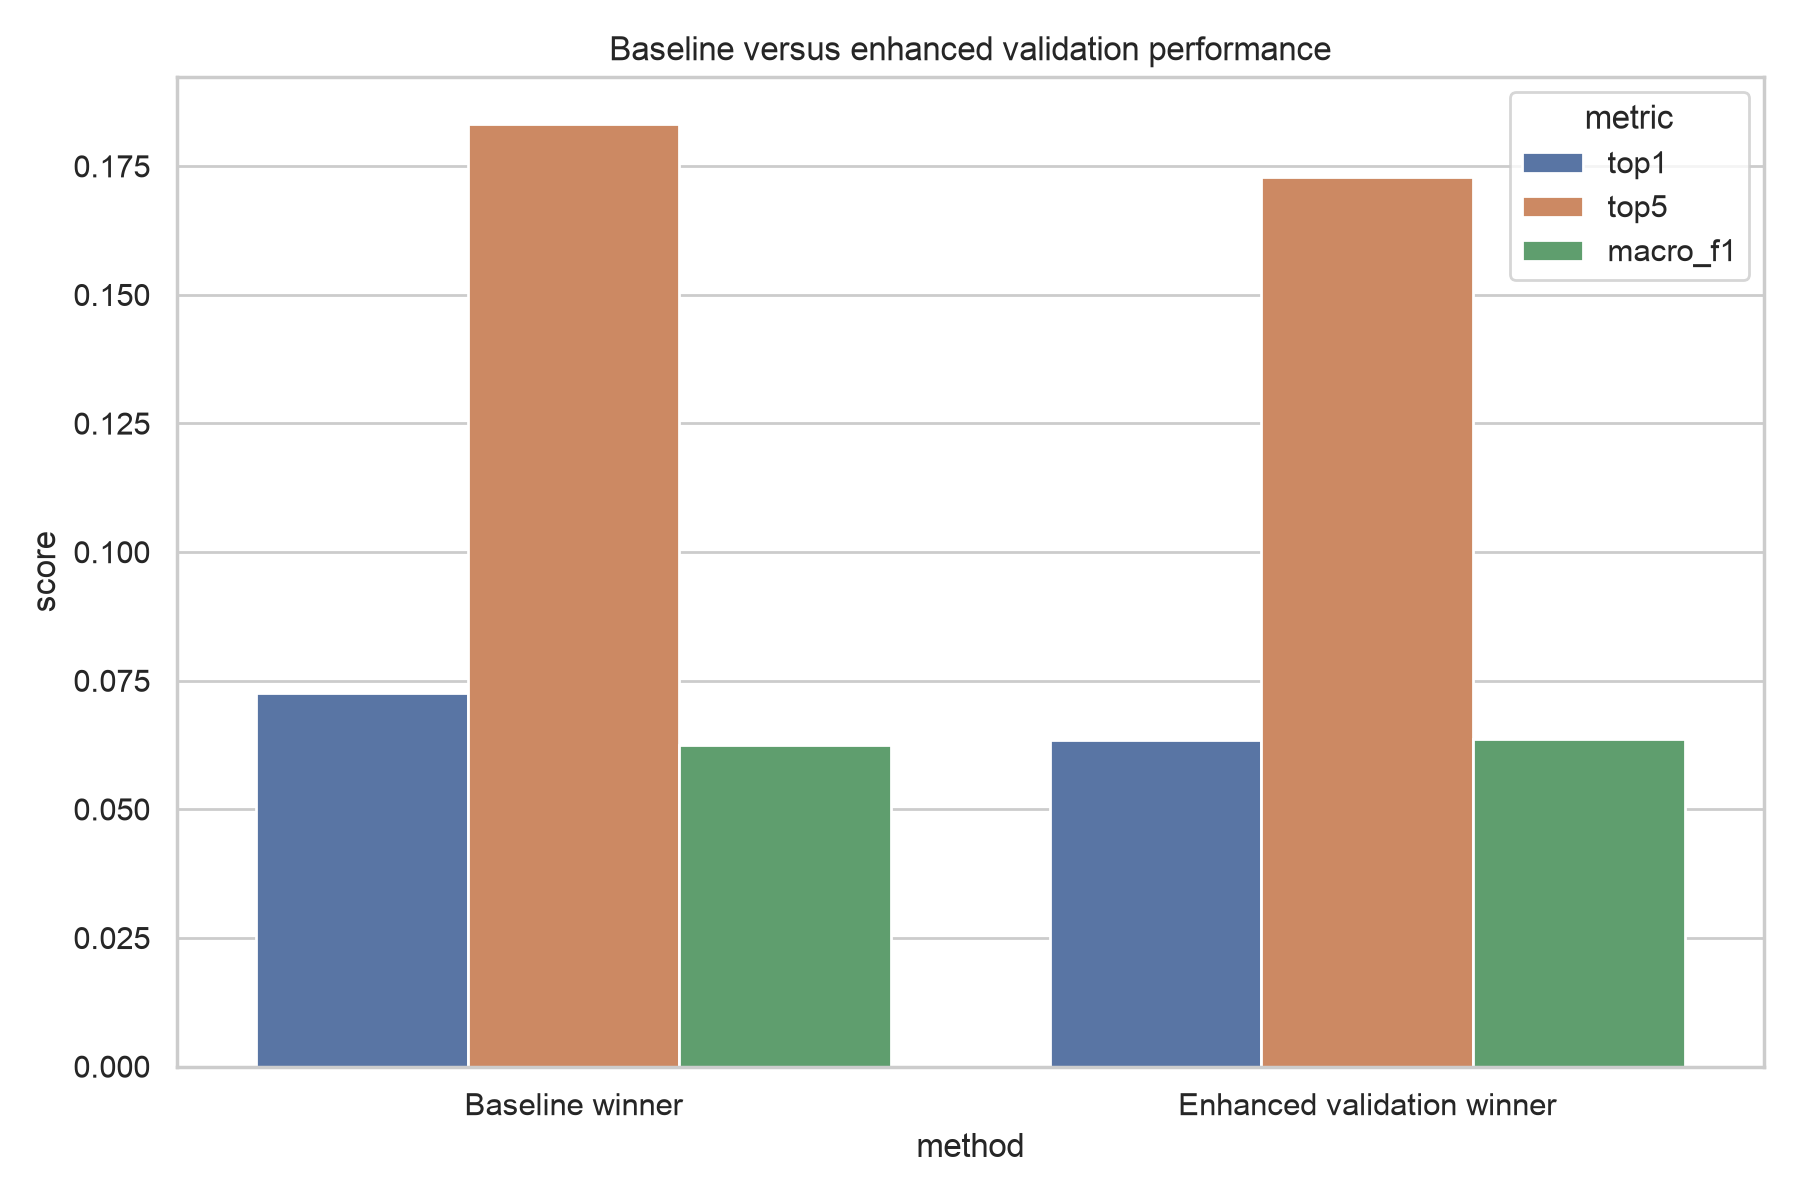

In [4]:
import json
import pandas as pd
from IPython.display import Image, display
selection = json.loads((OUTPUT / 'ENHANCED_COMPLETE.json').read_text())
display(pd.DataFrame([selection]))
display(pd.read_csv(OUTPUT / 'enhanced_validation_results.csv').sort_values('macro_f1', ascending=False))
for graph in ['metrics_comparison.png', 'train_validation_gap.png', 'performance_vs_time.png', 'baseline_vs_enhanced.png']:
    print(graph)
    display(Image(filename=str(OUTPUT / graph)))